# Citi Bike — Availability Improvement Notebook (State-Space + Capacity Aware)

This notebook is designed as **one more focused attempt to improve station availability prediction**.

Instead of treating availability as just another regression target, it uses a more physical update rule:

\[
A_{t+1} = 	ext{clip}(A_t + 	ext{arrivals}_{t+1} - 	ext{departures}_{t+1},\ 0,\ 	ext{capacity})
\]

That gives you three levels of comparison:

1. **Direct model**: predict next-hour availability directly.
2. **State-update model**: predict arrivals and departures separately, then update the station state.
3. **Hybrid residual model**: start from the state-update forecast, then learn a small correction.

Because the Citi Bike trip data does **not** contain true historical bike counts at every station-hour, this notebook first checks whether a true availability column already exists. If not, it builds a **bounded availability proxy** using hourly net flow and station capacity.

That makes this notebook useful in either case:
- **best case**: you already have a real availability signal in the table,
- **fallback case**: you still get a capacity-aware availability proxy that is more defensible than plain net-flow regression.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# If xgboost is missing in a fresh Colab runtime, run this cell once.
try:
    import xgboost  # noqa: F401
except Exception:
    %pip install -q xgboost

In [3]:
from pathlib import Path
import json
import math
import os
import re
import shutil
import subprocess
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import xgboost as xgb

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

RANDOM_STATE = 42
TOP_N_STATIONS = 100
TRAIN_FRAC = 0.70
VALID_FRAC = 0.15
LOW_AVAILABILITY_RATIO = 0.15

FEATURE_CACHE_CANDIDATES = [
    Path("/content/drive/MyDrive/feature_df_model_ready_2025_v6.parquet"),
    Path("/content/outputs/feature_df_model_ready_2025_v6.parquet"),
    Path("/content/feature_df_model_ready_2025_v6.parquet"),
    Path("/mnt/data/feature_df_model_ready_2025_v6.parquet"),
    Path("/mnt/data/outputs/feature_df_model_ready_2025_v6.parquet"),
    Path("/content/drive/MyDrive/feature_df_model_ready_2025_v5.parquet"),
    Path("/content/feature_df_model_ready_2025_v5.parquet"),
    Path("/mnt/data/feature_df_model_ready_2025_v5.parquet"),
]
STATION_LOOKUP_CANDIDATES = [
    Path("/content/station_lookup.csv"),
    Path("/mnt/data/station_lookup.csv"),
]
GBFS_STATION_INFO_URL = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_information.json"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


def locate_existing_path(candidates):
    for path in candidates:
        path = Path(path)
        if path.exists():
            return path
    return None


def detect_runtime_gpu():
    summary = {
        "nvidia_smi": False,
        "gpu_name": None,
        "xgboost_version": getattr(xgb, "__version__", "unknown"),
        "cuda_ready_for_xgb": False,
    }
    if shutil.which("nvidia-smi"):
        try:
            out = subprocess.check_output(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"], text=True)
            names = [line.strip() for line in out.splitlines() if line.strip()]
            if names:
                summary["nvidia_smi"] = True
                summary["gpu_name"] = names[0]
                summary["cuda_ready_for_xgb"] = True
        except Exception:
            pass
    return summary


GPU_INFO = detect_runtime_gpu()
print("XGBoost version:", GPU_INFO["xgboost_version"])
print("GPU detected by runtime:", GPU_INFO["nvidia_smi"])
print("GPU name:", GPU_INFO["gpu_name"])
print("XGBoost CUDA path enabled:", GPU_INFO["cuda_ready_for_xgb"])

feature_df_path = locate_existing_path(FEATURE_CACHE_CANDIDATES)
station_lookup_path = locate_existing_path(STATION_LOOKUP_CANDIDATES)
print("feature_df path:", feature_df_path)
print("station_lookup path:", station_lookup_path)

XGBoost version: 3.2.0
GPU detected by runtime: True
GPU name: NVIDIA L4
XGBoost CUDA path enabled: True
feature_df path: /content/drive/MyDrive/feature_df_model_ready_2025_v6.parquet
station_lookup path: /content/station_lookup.csv


## 1) Load the model-ready feature table

This notebook expects the same station-hour table used in the follow-on experiments.
It will then repair capacity if needed and build either a true or proxy availability target.


In [4]:
if feature_df_path is None:
    raise FileNotFoundError(
        "Could not find a model-ready feature table. Put feature_df_model_ready_2025_v6.parquet (or v5) in one of the candidate paths above."
    )

if feature_df_path.suffix.lower() == ".parquet":
    feature_df = pd.read_parquet(feature_df_path)
elif feature_df_path.suffix.lower() == ".csv":
    feature_df = pd.read_csv(feature_df_path)
else:
    raise ValueError(f"Unsupported feature table format: {feature_df_path.suffix}")

feature_df.columns = feature_df.columns.str.strip().str.lower()
if "hour" in feature_df.columns:
    feature_df["hour"] = pd.to_datetime(feature_df["hour"], errors="coerce")
if "station_key" in feature_df.columns:
    feature_df["station_key"] = feature_df["station_key"].astype("string")

print("Loaded feature_df shape:", feature_df.shape)
display(feature_df.head(3))

Loaded feature_df shape: (11966828, 66)


,station_key,hour,departures,arrivals,net_flow,total_activity,station_name,lat,lng,capacity,is_active_station,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°f),soil_temperature_7_to_28cm (°f),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,is_commute_peak,is_overnight,hour_sin,hour_cos,dow_sin,dow_cos,is_holiday,is_precipitating,heavy_precip_flag,is_raining,is_snowing,departures_lag_1,departures_lag_2,departures_lag_24,departures_roll_3,departures_roll_24,arrivals_lag_1,arrivals_lag_2,arrivals_lag_24,arrivals_roll_3,arrivals_roll_24,net_flow_lag_1,net_flow_lag_2,net_flow_lag_24,net_flow_roll_3,net_flow_roll_24,total_activity_lag_1,total_activity_lag_2,total_activity_lag_24,total_activity_roll_3,total_activity_roll_24,departures_next_hour,arrivals_next_hour,net_flow_next_hour,utilization_ratio,utilization_ratio_lag_1
0,1234.56,2025-06-18 22:00:00,0,1,1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0,22,2,6,0,0,0,0,-0.500000,0.866025,0.974928,-0.222521,0,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN
1,1234.56,2025-06-18 23:00:00,1,1,0,2,Morgan HCT Charging,40.708948,-73.932777,NaN,0,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0,23,2,6,0,0,0,0,-0.258819,0.965926,0.974928,-0.222521,0,1,0,1,0,0.0,NaN,NaN,0.0,0.0,1.0,NaN,NaN,1.0,1.0,1.0,NaN,NaN,1.0,1.0,1.0,NaN,NaN,1.0,1.0,1.0,0.0,-1.0,NaN,NaN
2,1234.56,2025-06-19 23:00:00,1,0,-1,1,Morgan HCT Charging,40.708948,-73.932777,NaN,0,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0,23,3,6,0,0,0,0,-0.258819,0.965926,0.433884,-0.900969,1,0,0,0,0,1.0,0.0,NaN,0.5,0.5,1.0,1.0,NaN,1.0,1.0,0.0,1.0,NaN,0.5,0.5,2.0,1.0,NaN,1.5,1.5,1.0,1.0,0.0,NaN,NaN


## 2) Repair capacity if needed

The state-update approach needs capacity. This cell reuses the GBFS-based repair idea from the follow-on notebook.


In [5]:
def _to_ascii_text(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    return x


def normalize_station_key(series):
    s = pd.Series(series, dtype="string")
    s = s.astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\s+", "", regex=True)
    return s


def normalize_station_name(series):
    s = pd.Series(series).map(_to_ascii_text).astype("string").str.lower()
    s = s.str.replace("&", " and ", regex=False)
    s = s.str.replace(r"[^a-z0-9]+", " ", regex=True)
    s = s.str.replace(r"\bavenue\b", "ave", regex=True)
    s = s.str.replace(r"\bstreet\b", "st", regex=True)
    s = s.str.replace(r"\bplace\b", "pl", regex=True)
    s = s.str.replace(r"\broad\b", "rd", regex=True)
    s = s.str.replace(r"\bparkway\b", "pkwy", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s


def unwrap_gbfs_name(x):
    if isinstance(x, list):
        parts = []
        for item in x:
            if isinstance(item, dict):
                txt = item.get("text")
                if txt:
                    parts.append(str(txt))
            elif item is not None:
                parts.append(str(item))
        return " ".join(parts) if parts else None
    return x


def fetch_gbfs_capacity(url=GBFS_STATION_INFO_URL):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    stations = response.json()["data"]["stations"]
    gbfs = pd.DataFrame(stations).copy()

    if "name" in gbfs.columns:
        gbfs["name"] = gbfs["name"].map(unwrap_gbfs_name)

    keep_cols = [c for c in ["station_id", "short_name", "name", "capacity", "lat", "lon"] if c in gbfs.columns]
    gbfs = gbfs[keep_cols].copy()

    gbfs["station_id_norm"] = normalize_station_key(gbfs.get("station_id"))
    gbfs["short_name_norm"] = normalize_station_key(gbfs.get("short_name"))
    gbfs["name_norm"] = normalize_station_name(gbfs.get("name"))
    gbfs["capacity"] = pd.to_numeric(gbfs.get("capacity"), errors="coerce")
    gbfs["lat_r4"] = pd.to_numeric(gbfs.get("lat"), errors="coerce").round(4)
    gbfs["lon_r4"] = pd.to_numeric(gbfs.get("lon"), errors="coerce").round(4)
    return gbfs


def first_capacity_map(df, key_cols):
    tmp = df.dropna(subset=key_cols + ["capacity"]).copy()
    tmp = tmp.groupby(key_cols, as_index=False)["capacity"].median()
    return tmp


def attach_capacity_to_station_lookup(station_lookup):
    sl = station_lookup.copy()
    sl.columns = sl.columns.str.strip().str.lower()
    gbfs = fetch_gbfs_capacity()

    code_col = next((c for c in ["station_id", "short_name", "station_code", "station_key"] if c in sl.columns), None)
    name_col = next((c for c in ["station_name", "name", "station_key"] if c in sl.columns), None)
    lat_col = next((c for c in ["lat", "latitude"] if c in sl.columns), None)
    lng_col = next((c for c in ["lng", "lon", "longitude"] if c in sl.columns), None)

    sl["code_norm"] = normalize_station_key(sl[code_col]) if code_col else pd.Series(pd.NA, index=sl.index, dtype="string")
    sl["name_norm"] = normalize_station_name(sl[name_col]) if name_col else pd.Series(pd.NA, index=sl.index, dtype="string")
    sl["lat_r4"] = pd.to_numeric(sl[lat_col], errors="coerce").round(4) if lat_col else np.nan
    sl["lng_r4"] = pd.to_numeric(sl[lng_col], errors="coerce").round(4) if lng_col else np.nan

    sl["capacity"] = np.nan
    sl["capacity_source"] = pd.NA

    short_map = first_capacity_map(gbfs, ["short_name_norm"]).rename(columns={"short_name_norm": "code_norm", "capacity": "capacity_short"})
    sl = sl.merge(short_map, on="code_norm", how="left")
    m = sl["capacity"].isna() & sl["capacity_short"].notna()
    sl.loc[m, "capacity"] = sl.loc[m, "capacity_short"]
    sl.loc[m, "capacity_source"] = "short_name"
    sl = sl.drop(columns=["capacity_short"])

    id_map = first_capacity_map(gbfs, ["station_id_norm"]).rename(columns={"station_id_norm": "code_norm", "capacity": "capacity_id"})
    sl = sl.merge(id_map, on="code_norm", how="left")
    m = sl["capacity"].isna() & sl["capacity_id"].notna()
    sl.loc[m, "capacity"] = sl.loc[m, "capacity_id"]
    sl.loc[m, "capacity_source"] = "station_id"
    sl = sl.drop(columns=["capacity_id"])

    name_map = first_capacity_map(gbfs, ["name_norm"]).rename(columns={"name_norm": "name_norm", "capacity": "capacity_name"})
    sl = sl.merge(name_map, on="name_norm", how="left")
    m = sl["capacity"].isna() & sl["capacity_name"].notna()
    sl.loc[m, "capacity"] = sl.loc[m, "capacity_name"]
    sl.loc[m, "capacity_source"] = "name"
    sl = sl.drop(columns=["capacity_name"])

    geo_map = first_capacity_map(gbfs, ["lat_r4", "lon_r4"]).rename(columns={"capacity": "capacity_geo"})
    sl = sl.merge(geo_map, left_on=["lat_r4", "lng_r4"], right_on=["lat_r4", "lon_r4"], how="left")
    m = sl["capacity"].isna() & sl["capacity_geo"].notna()
    sl.loc[m, "capacity"] = sl.loc[m, "capacity_geo"]
    sl.loc[m, "capacity_source"] = "geo"
    drop_cols = [c for c in ["capacity_geo", "lon_r4"] if c in sl.columns]
    sl = sl.drop(columns=drop_cols)
    return sl


def repair_capacity(feature_df, station_lookup_path=None):
    out = feature_df.copy()
    if "capacity" in out.columns and out["capacity"].notna().mean() > 0.80:
        return out

    if station_lookup_path is None or not Path(station_lookup_path).exists():
        raise FileNotFoundError("station_lookup.csv is needed to repair missing capacity values.")

    station_lookup = pd.read_csv(station_lookup_path)
    station_lookup = attach_capacity_to_station_lookup(station_lookup)
    station_lookup.columns = station_lookup.columns.str.strip().str.lower()

    key_col = next((c for c in ["station_key", "station_id", "station_code", "short_name"] if c in station_lookup.columns), None)
    name_col = next((c for c in ["station_name", "name"] if c in station_lookup.columns), None)

    if key_col is None:
        raise ValueError("No usable station key column found in station_lookup.csv")

    lookup_cols = [key_col, "capacity"]
    if name_col and name_col not in lookup_cols:
        lookup_cols.append(name_col)
    lookup = station_lookup[lookup_cols].copy()
    lookup = lookup.rename(columns={key_col: "station_key_lookup"})
    lookup["station_key_lookup"] = normalize_station_key(lookup["station_key_lookup"])

    if "station_key" not in out.columns:
        raise ValueError("feature_df must have station_key to repair capacity")

    out["station_key_norm"] = normalize_station_key(out["station_key"])
    out = out.merge(lookup[["station_key_lookup", "capacity"]].drop_duplicates(), left_on="station_key_norm", right_on="station_key_lookup", how="left", suffixes=("", "_lookup"))

    if "capacity" not in out.columns:
        out["capacity"] = np.nan
    m = out["capacity"].isna() & out["capacity_lookup"].notna()
    out.loc[m, "capacity"] = out.loc[m, "capacity_lookup"]
    out = out.drop(columns=[c for c in ["station_key_norm", "station_key_lookup", "capacity_lookup"] if c in out.columns])
    return out


feature_df = repair_capacity(feature_df, station_lookup_path=station_lookup_path)
print("Capacity non-null share:", round(feature_df["capacity"].notna().mean(), 4) if "capacity" in feature_df.columns else "missing")
print("Rows with capacity:", int(feature_df["capacity"].notna().sum()) if "capacity" in feature_df.columns else 0)


Capacity non-null share: 0.9923
Rows with capacity: 11874909


## 3) Narrow to the busiest stations and build the availability target

This notebook keeps the modeling scope manageable by using the busiest stations first.
It then tries to build the best possible current/next-hour availability target.


In [6]:
def busiest_station_keys(df, top_n=TOP_N_STATIONS):
    if "total_activity" in df.columns:
        ranking = df.groupby("station_key", observed=True)["total_activity"].sum().sort_values(ascending=False)
    elif {"arrivals", "departures"}.issubset(df.columns):
        ranking = (df.groupby("station_key", observed=True)["arrivals"].sum() + df.groupby("station_key", observed=True)["departures"].sum()).sort_values(ascending=False)
    else:
        ranking = df.groupby("station_key", observed=True).size().sort_values(ascending=False)
    return ranking.head(top_n).index.astype("string").tolist()


def detect_true_availability_col(df):
    candidates = [
        "num_bikes_available",
        "bikes_available",
        "available_bikes",
        "bike_availability",
        "availability_current",
        "availability",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def estimate_anchor_fill_ratio(df, capacity_col="capacity", delta_col="net_flow"):
    alphas = np.round(np.linspace(0.10, 0.90, 17), 2)
    rows = []
    work = df[["station_key", "service_date", capacity_col, delta_col]].dropna(subset=["station_key", "service_date", capacity_col, delta_col]).copy()

    for station_key, g in work.groupby("station_key", observed=True):
        cap = float(pd.to_numeric(g[capacity_col], errors="coerce").median())
        if not np.isfinite(cap) or cap <= 0:
            continue

        best_alpha = 0.50
        best_loss = np.inf
        for alpha in alphas:
            start = alpha * cap
            raw = g.groupby("service_date", observed=True)[delta_col].cumsum() + start
            clipped = raw.clip(lower=0, upper=cap)
            loss = float((raw - clipped).abs().sum())
            tie_break = abs(alpha - 0.50)
            if (loss < best_loss) or (math.isclose(loss, best_loss) and tie_break < abs(best_alpha - 0.50)):
                best_loss = loss
                best_alpha = float(alpha)
        rows.append({"station_key": station_key, "anchor_fill_ratio": best_alpha})

    return pd.DataFrame(rows)


def build_proxy_availability(df, capacity_col="capacity"):
    out = df.copy().sort_values(["station_key", "hour"]).reset_index(drop=True)
    if "net_flow" not in out.columns:
        if {"arrivals", "departures"}.issubset(out.columns):
            out["net_flow"] = out["arrivals"].fillna(0) - out["departures"].fillna(0)
        else:
            raise ValueError("Need either net_flow or both arrivals/departures to build the availability proxy.")

    out["service_date"] = out["hour"].dt.floor("D")
    anchors = estimate_anchor_fill_ratio(out, capacity_col=capacity_col, delta_col="net_flow")
    if len(anchors) == 0:
        raise ValueError("Could not estimate anchor fill ratios. Check capacity and net_flow columns.")

    out = out.merge(anchors, on="station_key", how="left")
    out["anchor_fill_ratio"] = out["anchor_fill_ratio"].fillna(0.50)
    out["anchor_bikes"] = out[capacity_col] * out["anchor_fill_ratio"]

    cum_flow = out.groupby(["station_key", "service_date"], observed=True)["net_flow"].cumsum()
    out["availability_current"] = (out["anchor_bikes"] + cum_flow).clip(lower=0, upper=out[capacity_col].fillna(0))
    out["availability_source"] = "proxy_from_net_flow_capacity"
    return out


feature_df = feature_df.dropna(subset=["station_key", "hour"]).copy()
feature_df["station_key"] = feature_df["station_key"].astype("string")

busy = busiest_station_keys(feature_df, top_n=TOP_N_STATIONS)
model_df = feature_df.loc[feature_df["station_key"].isin(busy)].copy()
model_df = model_df.dropna(subset=["capacity"]).copy()
model_df["capacity"] = pd.to_numeric(model_df["capacity"], errors="coerce")
model_df = model_df[model_df["capacity"] > 0].copy()

true_availability_col = detect_true_availability_col(model_df)
if true_availability_col is not None:
    model_df["availability_current"] = pd.to_numeric(model_df[true_availability_col], errors="coerce")
    model_df["availability_source"] = f"true_column:{true_availability_col}"
else:
    model_df = build_proxy_availability(model_df, capacity_col="capacity")

model_df = model_df.sort_values(["station_key", "hour"]).reset_index(drop=True)
model_df["availability_current"] = model_df["availability_current"].clip(lower=0, upper=model_df["capacity"])
model_df["availability_ratio_current"] = model_df["availability_current"] / model_df["capacity"].replace(0, np.nan)
model_df["availability_next_hour"] = model_df.groupby("station_key", observed=True)["availability_current"].shift(-1)
model_df["availability_ratio_next_hour"] = model_df.groupby("station_key", observed=True)["availability_ratio_current"].shift(-1)

print("Availability source:", model_df["availability_source"].dropna().iloc[0])
print("Modeling rows before feature engineering:", model_df.shape)
display(model_df[["station_key", "hour", "capacity", "availability_current", "availability_next_hour", "availability_source"]].head(10))

Availability source: proxy_from_net_flow_capacity
Modeling rows before feature engineering: (791837, 74)


,station_key,hour,capacity,availability_current,availability_next_hour,availability_source
0,4395.07,2025-01-01 00:00:00,39.0,6.75,4.75,proxy_from_net_flow_capacity
1,4395.07,2025-01-01 01:00:00,39.0,4.75,4.75,proxy_from_net_flow_capacity
2,4395.07,2025-01-01 02:00:00,39.0,4.75,6.75,proxy_from_net_flow_capacity
3,4395.07,2025-01-01 06:00:00,39.0,6.75,7.75,proxy_from_net_flow_capacity
4,4395.07,2025-01-01 07:00:00,39.0,7.75,6.75,proxy_from_net_flow_capacity
5,4395.07,2025-01-01 08:00:00,39.0,6.75,3.75,proxy_from_net_flow_capacity
6,4395.07,2025-01-01 09:00:00,39.0,3.75,4.75,proxy_from_net_flow_capacity
7,4395.07,2025-01-01 10:00:00,39.0,4.75,6.75,proxy_from_net_flow_capacity
8,4395.07,2025-01-01 11:00:00,39.0,6.75,2.75,proxy_from_net_flow_capacity
9,4395.07,2025-01-01 12:00:00,39.0,2.75,5.75,proxy_from_net_flow_capacity


## 4) Feature engineering for capacity-aware availability forecasting

This extends the best ideas from the earlier notebooks:
- multi-horizon lags and rolling windows,
- calendar structure,
- station activity profiles,
- capacity pressure,
- current availability as a state variable.


In [7]:
def add_base_time_features(df):
    out = df.copy().sort_values(["station_key", "hour"]).reset_index(drop=True)
    out["hour_of_day"] = out["hour"].dt.hour
    out["day_of_week"] = out["hour"].dt.dayofweek
    out["month"] = out["hour"].dt.month
    out["week_of_year"] = out["hour"].dt.isocalendar().week.astype(int)
    out["is_weekend"] = (out["day_of_week"] >= 5).astype(int)
    out["is_commute_peak"] = out["hour_of_day"].isin([7, 8, 9, 16, 17, 18]).astype(int)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour_of_day"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour_of_day"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["day_of_week"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["day_of_week"] / 7)
    if "is_holiday" not in out.columns:
        out["is_holiday"] = 0
    return out


def add_temporal_lags_and_rolls(df):
    out = df.copy().sort_values(["station_key", "hour"]).reset_index(drop=True)
    lag_bases = [c for c in ["departures", "arrivals", "net_flow", "total_activity", "availability_current", "availability_ratio_current"] if c in out.columns]
    lag_windows = [1, 2, 3, 6, 12, 24, 168]
    rolling_windows = [3, 6, 24]

    for base in lag_bases:
        grouped = out.groupby("station_key", observed=True)[base]
        for lag in lag_windows:
            out[f"{base}_lag_{lag}"] = grouped.shift(lag)
        for win in rolling_windows:
            out[f"{base}_roll_mean_{win}"] = grouped.transform(lambda s: s.shift(1).rolling(win, min_periods=1).mean())
            out[f"{base}_roll_std_{win}"] = grouped.transform(lambda s: s.shift(1).rolling(win, min_periods=2).std())
    return out


def add_capacity_engineered_features(df):
    out = df.copy()
    cap = out["capacity"].replace(0, np.nan)
    out["availability_pressure_current"] = 1.0 - (out["availability_current"] / cap)
    if "departures_roll_mean_24" in out.columns:
        out["departure_pressure_24h"] = out["departures_roll_mean_24"] / cap
    if "arrivals_roll_mean_24" in out.columns:
        out["arrival_pressure_24h"] = out["arrivals_roll_mean_24"] / cap
    if "total_activity_roll_mean_24" in out.columns:
        out["activity_pressure_24h"] = out["total_activity_roll_mean_24"] / cap
    return out


def add_simple_weather_interactions(df):
    out = df.copy()
    temp_col = next((c for c in ["temperature_f", "temperature_2m", "apparent_temperature_f"] if c in out.columns), None)
    rain_col = next((c for c in ["precipitation_in", "rain_in", "precipitation"] if c in out.columns), None)

    if temp_col is not None:
        out["temp_x_peak"] = pd.to_numeric(out[temp_col], errors="coerce") * out.get("is_commute_peak", 0)
    if rain_col is not None:
        rain_numeric = pd.to_numeric(out[rain_col], errors="coerce").fillna(0)
        out["is_precipitating"] = (rain_numeric > 0).astype(int)
        out["rain_x_peak"] = rain_numeric * out.get("is_commute_peak", 0)
    return out


model_df = add_base_time_features(model_df)
model_df = add_temporal_lags_and_rolls(model_df)
model_df = add_capacity_engineered_features(model_df)
model_df = add_simple_weather_interactions(model_df)

for target in ["departures_next_hour", "arrivals_next_hour", "net_flow_next_hour"]:
    if target not in model_df.columns:
        base = target.replace("_next_hour", "")
        if base in model_df.columns:
            model_df[target] = model_df.groupby("station_key", observed=True)[base].shift(-1)

# Some v6 tables do not contain `net_flow_next_hour` directly.
# Derive it from shifted arrivals/departures when possible.
if "net_flow_next_hour" not in model_df.columns and {"arrivals_next_hour", "departures_next_hour"}.issubset(model_df.columns):
    model_df["net_flow_next_hour"] = model_df["arrivals_next_hour"].fillna(0) - model_df["departures_next_hour"].fillna(0)

# Always expose the next-hour availability ratio for later slicing/alerts.
if "availability_ratio_next_hour" not in model_df.columns and {"availability_next_hour", "capacity"}.issubset(model_df.columns):
    cap = model_df["capacity"].replace(0, np.nan)
    model_df["availability_ratio_next_hour"] = model_df["availability_next_hour"] / cap

print("Feature-engineered shape:", model_df.shape)
display(model_df.head(3))


Feature-engineered shape: (791837, 147)


,station_key,hour,departures,arrivals,net_flow,total_activity,station_name,lat,lng,capacity,is_active_station,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°f),soil_temperature_7_to_28cm (°f),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,is_commute_peak,is_overnight,hour_sin,hour_cos,dow_sin,dow_cos,is_holiday,is_precipitating,heavy_precip_flag,is_raining,is_snowing,departures_lag_1,departures_lag_2,departures_lag_24,departures_roll_3,departures_roll_24,arrivals_lag_1,arrivals_lag_2,arrivals_lag_24,arrivals_roll_3,arrivals_roll_24,net_flow_lag_1,net_flow_lag_2,net_flow_lag_24,net_flow_roll_3,net_flow_roll_24,total_activity_lag_1,total_activity_lag_2,total_activity_lag_24,total_activity_roll_3,total_activity_roll_24,departures_next_hour,arrivals_next_hour,net_flow_next_hour,utilization_ratio,utilization_ratio_lag_1,service_date,anchor_fill_ratio,anchor_bikes,availability_current,availability_source,availability_ratio_current,availability_next_hour,availability_ratio_next_hour,week_of_year,departures_lag_3,departures_lag_6,departures_lag_12,departures_lag_168,departures_roll_mean_3,departures_roll_std_3,departures_roll_mean_6,departures_roll_std_6,departures_roll_mean_24,departures_roll_std_24,arrivals_lag_3,arrivals_lag_6,arrivals_lag_12,arrivals_lag_168,arrivals_roll_mean_3,arrivals_roll_std_3,arrivals_roll_mean_6,arrivals_roll_std_6,arrivals_roll_mean_24,arrivals_roll_std_24,net_flow_lag_3,net_flow_lag_6,net_flow_lag_12,net_flow_lag_168,net_flow_roll_mean_3,net_flow_roll_std_3,net_flow_roll_mean_6,net_flow_roll_std_6,net_flow_roll_mean_24,net_flow_roll_std_24,total_activity_lag_3,total_activity_lag_6,total_activity_lag_12,total_activity_lag_168,total_activity_roll_mean_3,total_activity_roll_std_3,total_activity_roll_mean_6,total_activity_roll_std_6,total_activity_roll_mean_24,total_activity_roll_std_24,availability_current_lag_1,availability_current_lag_2,availability_current_lag_3,availability_current_lag_6,availability_current_lag_12,availability_current_lag_24,availability_current_lag_168,availability_current_roll_mean_3,availability_current_roll_std_3,availability_current_roll_mean_6,availability_current_roll_std_6,availability_current_roll_mean_24,availability_current_roll_std_24,availability_ratio_current_lag_1,availability_ratio_current_lag_2,availability_ratio_current_lag_3,availability_ratio_current_lag_6,availability_ratio_current_lag_12,availability_ratio_current_lag_24,availability_ratio_current_lag_168,availability_ratio_current_roll_mean_3,availability_ratio_current_roll_std_3,availability_ratio_current_roll_mean_6,availability_ratio_current_roll_std_6,availability_ratio_current_roll_mean_24,availability_ratio_current_roll_std_24,availability_pressure_current,departure_pressure_24h,arrival_pressure_24h,activity_pressure_24h,temp_x_peak,rain_x_peak
0,4395.07,2025-01-01 00:00:00,4,1,-3,5,Hanson Pl & Ashland Pl,40.685068,-73.977908,39.0,0,0.0,45.6,0.146,0.146,0.0,0.0,10.7,44.3,43.7,94.0,44.0,39.5,22.4,91.0,0,2,1,0,0,0,1,0.000000,1.000000,0.974928,-0.222521,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,1.0,-2.0,NaN,NaN,2025-01-01,0.25,9.75,6.75,proxy_from_net_flow_capacity,0.173077,4.75,0.121795,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.826923,NaN,NaN,NaN,0.0,0.0
1,4395.07,2025-01-01 01:00:00,3,1,-2,4,Hanson Pl & Ashland Pl,40.685068,-73.977908,39.0,0,0.0,46.8,0.035,0.035,0.0,0.0,9.3,44.6,43.7,96.0,45.8,41.8,23.7,92.0,1,2,1,0,0,0,1,0.258819,0.965926,0.974928,-0.222521,1,1,0,1,0,4.0,NaN,NaN,4.0,4.0,1.0,NaN,NaN,1.0,1.0,-3.0,NaN,NaN,-3.0,-3.0,5.0,NaN,NaN,5.0,5.0,1.0,1.0,0.0,NaN,NaN

## 5) Split utilities, metrics, and model helpers

In [8]:
def chronological_split(df, time_col="hour", train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC):
    out = df.sort_values(time_col).copy()
    unique_times = np.array(sorted(pd.to_datetime(out[time_col].dropna().unique())))
    if len(unique_times) < 10:
        raise ValueError("Not enough unique timestamps for a stable chronological split.")

    train_end_idx = max(1, int(len(unique_times) * train_frac))
    valid_end_idx = max(train_end_idx + 1, int(len(unique_times) * (train_frac + valid_frac)))

    train_end_time = unique_times[train_end_idx - 1]
    valid_end_time = unique_times[min(valid_end_idx - 1, len(unique_times) - 1)]

    train_df = out[out[time_col] <= train_end_time].copy()
    valid_df = out[(out[time_col] > train_end_time) & (out[time_col] <= valid_end_time)].copy()
    test_df = out[out[time_col] > valid_end_time].copy()
    return train_df, valid_df, test_df


def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "rmse": rmse,
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def classification_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan,
    }


def apply_train_only_station_profiles(train_df, valid_df, test_df):
    frames = []
    for frame in [train_df.copy(), valid_df.copy(), test_df.copy()]:
        frame["station_key"] = frame["station_key"].astype("string")
        frames.append(frame)
    train_df, valid_df, test_df = frames

    base_measure = "availability_current"
    station_hour = train_df.groupby(["station_key", "hour_of_day"], as_index=False)[base_measure].mean().rename(columns={base_measure: "station_hour_avg_availability"})
    station_weekday_hour = train_df.groupby(["station_key", "day_of_week", "hour_of_day"], as_index=False)[base_measure].mean().rename(columns={base_measure: "station_weekday_hour_avg_availability"})
    station_mean = train_df.groupby("station_key", as_index=False)[base_measure].mean().rename(columns={base_measure: "station_avg_availability"})
    station_std = train_df.groupby("station_key", as_index=False)[base_measure].std().rename(columns={base_measure: "station_availability_std"})

    for idx, frame in enumerate([train_df, valid_df, test_df]):
        frame = frame.merge(station_hour, on=["station_key", "hour_of_day"], how="left")
        frame = frame.merge(station_weekday_hour, on=["station_key", "day_of_week", "hour_of_day"], how="left")
        frame = frame.merge(station_mean, on=["station_key"], how="left")
        frame = frame.merge(station_std, on=["station_key"], how="left")
        if idx == 0:
            train_df = frame
        elif idx == 1:
            valid_df = frame
        else:
            test_df = frame

    profile_cols = [
        "station_hour_avg_availability",
        "station_weekday_hour_avg_availability",
        "station_avg_availability",
        "station_availability_std",
    ]
    return train_df, valid_df, test_df, profile_cols


def clean_xgb_frames(train_df, valid_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_valid = valid_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    for frame in [X_train, X_valid, X_test]:
        frame.replace([np.inf, -np.inf], np.nan, inplace=True)

    cat_cols = []
    for col in feature_cols:
        dtype_name = str(X_train[col].dtype)
        if dtype_name in ["object", "string", "category"]:
            cat_cols.append(col)
        elif dtype_name == "bool":
            for frame in [X_train, X_valid, X_test]:
                frame[col] = frame[col].astype("int8")

    for col in cat_cols:
        categories = pd.Index(
            pd.concat([
                X_train[col].astype("string"),
                X_valid[col].astype("string"),
                X_test[col].astype("string"),
            ]).fillna("__nan__").unique()
        )
        for frame in [X_train, X_valid, X_test]:
            frame[col] = pd.Categorical(frame[col].astype("string").fillna("__nan__"), categories=categories)

    return X_train, X_valid, X_test


def fit_xgb_regressor(train_df, valid_df, test_df, target_col, feature_cols):
    X_train, X_valid, X_test = clean_xgb_frames(train_df, valid_df, test_df, feature_cols)
    y_train = train_df[target_col].astype(float)
    y_valid = valid_df[target_col].astype(float)

    params = dict(
        objective="reg:squarederror",
        eval_metric="rmse",
        n_estimators=400,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=4,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.0,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=RANDOM_STATE,
        early_stopping_rounds=40,
        enable_categorical=True,
    )
    if GPU_INFO["cuda_ready_for_xgb"]:
        params["device"] = "cuda"

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)
    return model, valid_pred, test_pred


def fit_rf_regressor(train_df, valid_df, test_df, target_col, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_valid = valid_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()
    y_train = train_df[target_col].astype(float)

    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_train[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", ohe)]), categorical_cols),
        ],
        remainder="drop",
    )

    model = Pipeline([
        ("prep", preprocessor),
        ("rf", RandomForestRegressor(
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])
    model.fit(X_train, y_train)
    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)
    return model, valid_pred, test_pred

## 6) Build the modeling frame and compare direct availability models

This is the simplest benchmark for the new notebook: predict `availability_next_hour` directly.


In [9]:
base_feature_candidates = [
    "station_key", "hour_of_day", "day_of_week", "month", "week_of_year", "is_weekend", "is_commute_peak", "is_holiday",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "capacity", "availability_current", "availability_ratio_current", "availability_pressure_current",
    "departures", "arrivals", "net_flow", "total_activity",
    "departure_pressure_24h", "arrival_pressure_24h", "activity_pressure_24h",
    "is_precipitating", "temp_x_peak", "rain_x_peak",
    "temperature_f", "precipitation_in", "rain_in", "wind_speed_mph", "relative_humidity_pct",
]

for prefix in ["departures", "arrivals", "net_flow", "total_activity", "availability_current", "availability_ratio_current"]:
    for lag in [1, 2, 3, 6, 12, 24, 168]:
        base_feature_candidates.append(f"{prefix}_lag_{lag}")
    for win in [3, 6, 24]:
        base_feature_candidates.append(f"{prefix}_roll_mean_{win}")
        base_feature_candidates.append(f"{prefix}_roll_std_{win}")

base_feature_candidates = [c for c in dict.fromkeys(base_feature_candidates) if c in model_df.columns]
required_cols = ["station_key", "hour", "availability_next_hour"]
frame_cols = [c for c in dict.fromkeys(required_cols + base_feature_candidates) if c in model_df.columns]
model_frame = model_df[frame_cols].dropna(subset=["availability_next_hour"]).copy()
model_frame = model_frame.sort_values(["hour", "station_key"]).reset_index(drop=True)

train_df, valid_df, test_df = chronological_split(model_frame)
train_df, valid_df, test_df, profile_cols = apply_train_only_station_profiles(train_df, valid_df, test_df)
feature_cols = [c for c in dict.fromkeys(base_feature_candidates + [c for c in profile_cols if c in train_df.columns]) if c in train_df.columns]

print("Train/valid/test rows:", len(train_df), len(valid_df), len(test_df))
print("Direct-model feature count:", len(feature_cols))

_, xgb_valid_pred_direct, xgb_test_pred_direct = fit_xgb_regressor(train_df, valid_df, test_df, "availability_next_hour", feature_cols)
_, rf_valid_pred_direct, rf_test_pred_direct = fit_rf_regressor(train_df, valid_df, test_df, "availability_next_hour", feature_cols)

direct_results = pd.DataFrame([
    {
        "model": "Direct availability — XGBoost",
        "valid_rmse": regression_metrics(valid_df["availability_next_hour"], xgb_valid_pred_direct)["rmse"],
        "valid_r2": regression_metrics(valid_df["availability_next_hour"], xgb_valid_pred_direct)["r2"],
        "test_rmse": regression_metrics(test_df["availability_next_hour"], xgb_test_pred_direct)["rmse"],
        "test_r2": regression_metrics(test_df["availability_next_hour"], xgb_test_pred_direct)["r2"],
    },
    {
        "model": "Direct availability — Random Forest",
        "valid_rmse": regression_metrics(valid_df["availability_next_hour"], rf_valid_pred_direct)["rmse"],
        "valid_r2": regression_metrics(valid_df["availability_next_hour"], rf_valid_pred_direct)["r2"],
        "test_rmse": regression_metrics(test_df["availability_next_hour"], rf_test_pred_direct)["rmse"],
        "test_r2": regression_metrics(test_df["availability_next_hour"], rf_test_pred_direct)["r2"],
    },
]).sort_values("test_r2", ascending=False).reset_index(drop=True)

display(direct_results)


Train/valid/test rows: 556828 119691 115219
Direct-model feature count: 113


,model,valid_rmse,valid_r2,test_rmse,test_r2
0,Direct availability — XGBoost,5.186065,0.942314,4.201642,0.951008
1,Direct availability — Random Forest,5.594589,0.932868,4.437386,0.945356


## 7) State-update model: forecast flows, then update station availability

This is the core new idea of the notebook.
Instead of forcing the model to learn availability end-to-end, it predicts the easier pieces first:
- next-hour arrivals,
- next-hour departures,
- then applies the station-balance equation with capacity clipping.


In [10]:
flow_feature_candidates = [c for c in feature_cols if c not in ["departures_next_hour", "arrivals_next_hour", "net_flow_next_hour"]]
flow_required = ["station_key", "hour", "availability_current", "capacity", "departures_next_hour", "arrivals_next_hour", "net_flow_next_hour", "availability_next_hour"]
flow_frame = model_df[[c for c in dict.fromkeys(flow_required + flow_feature_candidates) if c in model_df.columns]].copy()

if "net_flow_next_hour" not in flow_frame.columns and {"arrivals_next_hour", "departures_next_hour"}.issubset(flow_frame.columns):
    flow_frame["net_flow_next_hour"] = flow_frame["arrivals_next_hour"].fillna(0) - flow_frame["departures_next_hour"].fillna(0)

flow_frame = flow_frame.dropna(subset=["availability_next_hour", "departures_next_hour", "arrivals_next_hour"]).copy()
flow_frame = flow_frame.sort_values(["hour", "station_key"]).reset_index(drop=True)

train_flow, valid_flow, test_flow = chronological_split(flow_frame)
train_flow, valid_flow, test_flow, flow_profile_cols = apply_train_only_station_profiles(train_flow, valid_flow, test_flow)
flow_features = [c for c in dict.fromkeys(flow_feature_candidates + [c for c in flow_profile_cols if c in train_flow.columns]) if c in train_flow.columns]

dep_model, dep_valid_pred, dep_test_pred = fit_xgb_regressor(train_flow, valid_flow, test_flow, "departures_next_hour", flow_features)
arr_model, arr_valid_pred, arr_test_pred = fit_xgb_regressor(train_flow, valid_flow, test_flow, "arrivals_next_hour", flow_features)

valid_state_pred = (valid_flow["availability_current"] + arr_valid_pred - dep_valid_pred).clip(lower=0, upper=valid_flow["capacity"]).to_numpy()
test_state_pred = (test_flow["availability_current"] + arr_test_pred - dep_test_pred).clip(lower=0, upper=test_flow["capacity"]).to_numpy()

state_results = pd.DataFrame([
    {
        "model": "State update — XGBoost flows",
        "valid_rmse": regression_metrics(valid_flow["availability_next_hour"], valid_state_pred)["rmse"],
        "valid_r2": regression_metrics(valid_flow["availability_next_hour"], valid_state_pred)["r2"],
        "test_rmse": regression_metrics(test_flow["availability_next_hour"], test_state_pred)["rmse"],
        "test_r2": regression_metrics(test_flow["availability_next_hour"], test_state_pred)["r2"],
    }
])

display(state_results)


,model,valid_rmse,valid_r2,test_rmse,test_r2
0,State update — XGBoost flows,6.079761,0.92072,5.247514,0.923582


## 8) Hybrid residual model

This last model starts from the physical state-update forecast and only learns the residual correction.
That lets the notebook combine:
- a structure-aware baseline,
- and a flexible nonlinear correction.


In [11]:
train_h, valid_h, test_h = train_flow.copy(), valid_flow.copy(), test_flow.copy()

# For the train split we use the observed next-hour flow to create a residual target.
# For valid/test we use the fully predicted state-update baseline.
if "net_flow_next_hour" not in train_h.columns and {"arrivals_next_hour", "departures_next_hour"}.issubset(train_h.columns):
    train_h["net_flow_next_hour"] = train_h["arrivals_next_hour"].fillna(0) - train_h["departures_next_hour"].fillna(0)

train_h["state_baseline"] = (train_h["availability_current"] + train_h["net_flow_next_hour"].fillna(0)).clip(lower=0, upper=train_h["capacity"])
valid_h["state_baseline"] = valid_state_pred
test_h["state_baseline"] = test_state_pred

train_h["availability_residual"] = train_h["availability_next_hour"] - train_h["state_baseline"]
valid_h["availability_residual"] = valid_h["availability_next_hour"] - valid_h["state_baseline"]
test_h["availability_residual"] = test_h["availability_next_hour"] - test_h["state_baseline"]

hybrid_features = [c for c in dict.fromkeys(flow_features + ["state_baseline"]) if c in train_h.columns]
_, valid_resid_pred, test_resid_pred = fit_xgb_regressor(train_h, valid_h, test_h, "availability_residual", hybrid_features)

valid_hybrid_pred = (valid_h["state_baseline"] + valid_resid_pred).clip(lower=0, upper=valid_h["capacity"]).to_numpy()
test_hybrid_pred = (test_h["state_baseline"] + test_resid_pred).clip(lower=0, upper=test_h["capacity"]).to_numpy()

hybrid_results = pd.DataFrame([
    {
        "model": "Hybrid availability — state update + residual XGBoost",
        "valid_rmse": regression_metrics(valid_h["availability_next_hour"], valid_hybrid_pred)["rmse"],
        "valid_r2": regression_metrics(valid_h["availability_next_hour"], valid_hybrid_pred)["r2"],
        "test_rmse": regression_metrics(test_h["availability_next_hour"], test_hybrid_pred)["rmse"],
        "test_r2": regression_metrics(test_h["availability_next_hour"], test_hybrid_pred)["r2"],
    }
])

display(hybrid_results)


,model,valid_rmse,valid_r2,test_rmse,test_r2
0,Hybrid availability — state update + residual ...,5.258353,0.940695,4.382224,0.946706


## 9) Compare all approaches side by side

,model,valid_rmse,valid_r2,test_rmse,test_r2
0,Direct availability — XGBoost,5.186065,0.942314,4.201642,0.951008
1,Hybrid availability — state update + residual ...,5.258353,0.940695,4.382224,0.946706
2,Direct availability — Random Forest,5.594589,0.932868,4.437386,0.945356
3,State update — XGBoost flows,6.079761,0.920720,5.247514,0.923582


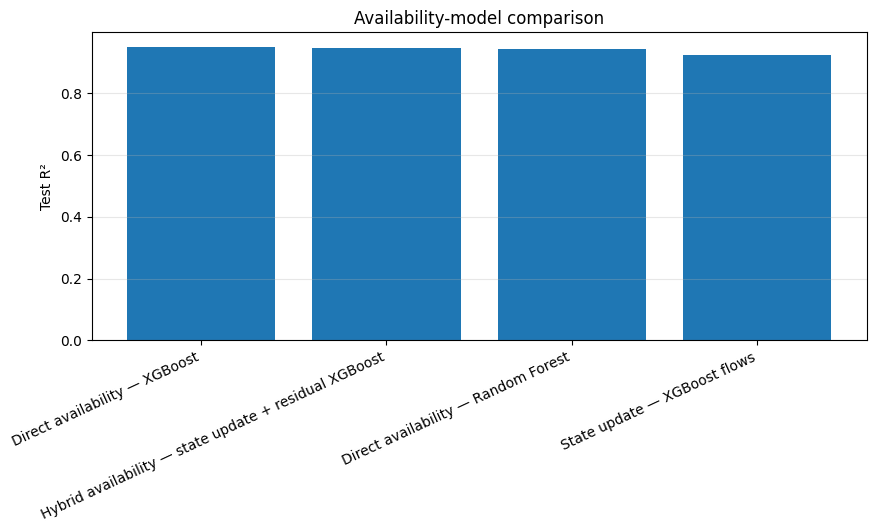

In [12]:
all_results = pd.concat([direct_results, state_results, hybrid_results], ignore_index=True)
all_results = all_results.sort_values("test_r2", ascending=False).reset_index(drop=True)
display(all_results)

plt.figure(figsize=(10, 4))
plt.bar(all_results["model"], all_results["test_r2"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Test R²")
plt.title("Availability-model comparison")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 10) Low-availability alert evaluation

Even if exact bike-count prediction is still noisy, the more practical operational question is often:
**Will this station be at low availability next hour?**


In [13]:
eval_df = test_h.copy()
eval_df["prediction_direct"] = xgb_test_pred_direct[:len(eval_df)] if len(xgb_test_pred_direct) == len(eval_df) else np.nan
eval_df["prediction_state"] = test_state_pred
eval_df["prediction_hybrid"] = test_hybrid_pred
eval_df["actual_low_availability"] = (eval_df["availability_next_hour"] / eval_df["capacity"] <= LOW_AVAILABILITY_RATIO).astype(int)

alert_rows = []
for pred_col, label in [
    ("prediction_state", "State update"),
    ("prediction_hybrid", "Hybrid residual"),
]:
    pred_ratio = eval_df[pred_col] / eval_df["capacity"]
    pred_prob_like = (LOW_AVAILABILITY_RATIO - pred_ratio).clip(lower=0)
    pred_prob_like = pred_prob_like / max(LOW_AVAILABILITY_RATIO, 1e-6)
    metrics = classification_metrics(eval_df["actual_low_availability"], pred_prob_like)
    metrics["model"] = label
    alert_rows.append(metrics)

alert_results = pd.DataFrame(alert_rows)[["model", "precision", "recall", "f1", "roc_auc"]].sort_values("f1", ascending=False)
display(alert_results)

,model,precision,recall,f1,roc_auc
1,Hybrid residual,0.962274,0.414669,0.579581,0.867373
0,State update,0.914642,0.406203,0.562565,0.860069


## 11) Error slicing

This helps answer whether the new approach improved exactly where the earlier notebooks struggled: rush hour and near-empty conditions.


### MAE by `hour_of_day`

,hour_of_day,abs_error
16,16,4.355190
7,7,4.239248
17,17,4.194860
15,15,3.948371
8,8,3.810668
18,18,3.633704
14,14,3.551779
6,6,3.388726
13,13,3.388113
12,12,3.238865


### MAE by `is_weekend`

,is_weekend,abs_error
0,0,3.154792
1,1,2.955221


### MAE by `is_commute_peak`

,is_commute_peak,abs_error
1,1,3.906509
0,0,2.789837


### MAE by `availability_bucket`

,availability_bucket,abs_error
4,very high,3.300605
3,high,3.165525
1,low,3.112366
0,very low,3.003914
2,mid,2.897429


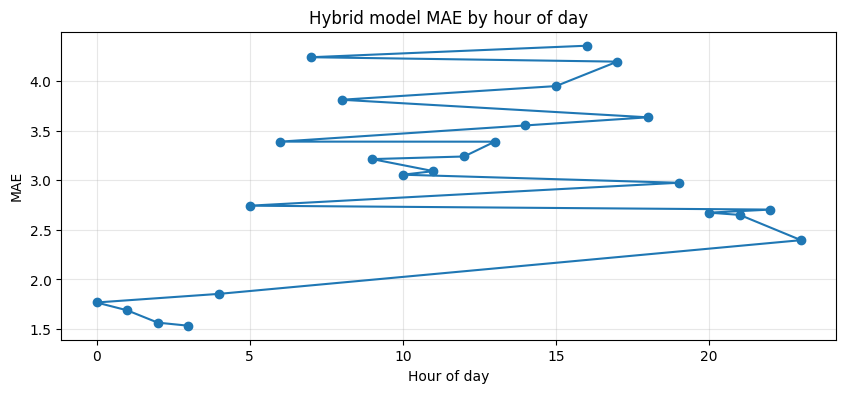

In [14]:
error_df = test_h.copy()
error_df["prediction"] = test_hybrid_pred
error_df["abs_error"] = (error_df["availability_next_hour"] - error_df["prediction"]).abs()
error_df["hour_of_day"] = pd.to_datetime(error_df["hour"]).dt.hour

if "availability_ratio_next_hour" not in error_df.columns and {"availability_next_hour", "capacity"}.issubset(error_df.columns):
    cap = error_df["capacity"].replace(0, np.nan)
    error_df["availability_ratio_next_hour"] = error_df["availability_next_hour"] / cap

error_df["availability_bucket"] = pd.qcut(
    error_df["availability_ratio_next_hour"].rank(method="first"),
    q=5,
    labels=["very low", "low", "mid", "high", "very high"],
)

slice_tables = {}
for col in ["hour_of_day", "is_weekend", "is_commute_peak", "availability_bucket"]:
    if col in error_df.columns:
        slice_tables[col] = error_df.groupby(col, as_index=False)["abs_error"].mean().sort_values("abs_error", ascending=False)

for name, table in slice_tables.items():
    display(Markdown(f"### MAE by `{name}`"))
    display(table.head(20))

if "hour_of_day" in slice_tables:
    plt.figure(figsize=(10, 4))
    plt.plot(slice_tables["hour_of_day"]["hour_of_day"], slice_tables["hour_of_day"]["abs_error"], marker="o")
    plt.title("Hybrid model MAE by hour of day")
    plt.xlabel("Hour of day")
    plt.ylabel("MAE")
    plt.grid(True, alpha=0.3)
    plt.show()


## 12) Save outputs for the report

These files make it easier to compare this notebook with the follow-on experiments notebook.


In [15]:
all_results.to_csv(OUTPUT_DIR / "availability_model_comparison.csv", index=False)
alert_results.to_csv(OUTPUT_DIR / "availability_alert_results.csv", index=False)
error_df[["station_key", "hour", "availability_next_hour", "prediction", "abs_error"]].to_csv(OUTPUT_DIR / "availability_test_predictions.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "availability_model_comparison.csv")
print(OUTPUT_DIR / "availability_alert_results.csv")
print(OUTPUT_DIR / "availability_test_predictions.csv")

Saved:
outputs/availability_model_comparison.csv
outputs/availability_alert_results.csv
outputs/availability_test_predictions.csv


## 13) How to interpret the results

A strong outcome pattern would look like this:

- the **state-update** model beats the direct availability model,
- the **hybrid residual** model improves further,
- low-availability alerting is stronger than exact-count regression,
- and the worst errors are still concentrated in commute peaks or very-low-availability states.

If that happens, the report story becomes much stronger:

> Availability prediction improves when the problem is reformulated as a **capacity-aware station state update**, rather than a single black-box regression target.
